In [1]:
# Import required packages

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import Point
from scipy.stats import gamma,norm,fisk,wilcoxon
from sklearn.cluster import KMeans
import sys
import gc
from pathlib import Path
import logging
from matplotlib.patches import Patch

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

In [2]:
# Configuration
config = {
    'casr_input_dir': project_root / 'Snow_Drought_Framework' / 'Data'  / 'output_data' / 'SWEI'/'Alberta_casr_daily_all_new.csv',
    'drought_subset_dir': project_root / 'Snow_Drought_Framework' / 'Data' / 'output_data' / 'SWEI'/'Drought_Years_by_Elevation.csv',
    'shapefile': project_root / 'Snow_Drought_Framework' / 'Data' / 'output_data' / 'elevation' / 'Alberta_elevation_combined.shp',
    'output_dir': project_root / 'Snow_Drought_Framework' / 'Data' / 'output_data' / 'Classification',
    'output_plots': project_root / 'Snow_Drought_Framework' / 'Data' / 'output_plots' / 'Classification'
}

In [3]:
# load the CASR data
casr_data = pd.read_csv(config['casr_input_dir'])
display(casr_data.head())

,Grid_ID,time,lat,lon,elev_class,Precipitation,SWE,Seasonal_Year
0,1825,1980-10-01,49.0062,-110.4268,1000_1500m,0.000000,0.0,1980
1,1846,1980-10-01,49.0298,-110.2956,1000_1500m,0.000000,0.0,1980
2,1865,1980-10-01,49.0533,-110.1643,1000_1500m,0.000000,0.0,1980
3,1885,1980-10-01,49.0765,-110.0329,1000_1500m,0.008709,0.0,1980
4,1842,1980-10-01,49.0211,-110.8567,1000_1500m,0.260985,0.0,1980


In [4]:
# find peak SWE per each Grid point and Seasonala_Year
peak_idx = (
    casr_data
    .loc[casr_data['SWE'].notna()]
    .groupby(['Grid_ID', 'Seasonal_Year'])['SWE']
    .idxmax()
)

peak_SWE_data = (
    casr_data
    .loc[peak_idx, ['Grid_ID', 'elev_class','lon','lat','Seasonal_Year', 'time', 'SWE']]
    .rename(columns={'time': 'Peak_SWE_Date', 'SWE': 'Peak_SWE'})
    .reset_index(drop=True)
)

display(peak_SWE_data.head())

,Grid_ID,elev_class,lon,lat,Seasonal_Year,Peak_SWE_Date,Peak_SWE
0,1823,1000_1500m,-112.4088,49.0028,1980,1981-02-08,24.4375
1,1823,1000_1500m,-112.4088,49.0028,1981,1982-03-25,46.2500
2,1823,1000_1500m,-112.4088,49.0028,1982,1982-11-21,17.8750
3,1823,1000_1500m,-112.4088,49.0028,1983,1983-12-31,33.5000
4,1823,1000_1500m,-112.4088,49.0028,1984,1985-03-03,40.3750


In [5]:
# calculate meanpeak SWE per Elevation category and Seasonal Year
mean_peak_SWE = (
    peak_SWE_data
    .groupby(['elev_class', 'Seasonal_Year'], as_index=False)
    .agg(Mean_Peak_SWE=('Peak_SWE', 'mean'))
)
display(mean_peak_SWE.head())

,elev_class,Seasonal_Year,Mean_Peak_SWE
0,0_500m,1980,103.993157
1,0_500m,1981,113.597388
2,0_500m,1982,136.846890
3,0_500m,1983,79.861341
4,0_500m,1984,132.457751


In [6]:
# compute climatological peak SWE per Elevation category 1991-2020
clim_peak_SWE = (
    mean_peak_SWE
    .loc[mean_peak_SWE['Seasonal_Year'].between(1991, 2020)]
    .groupby('elev_class', as_index=False)
    .agg(Climatological_Peak_SWE=('Mean_Peak_SWE', 'mean'))
)   
display(clim_peak_SWE.head())

,elev_class,Climatological_Peak_SWE
0,0_500m,107.367150
1,1000_1500m,62.826138
2,1500_2000m,116.367265
3,2000_2500m,168.419924
4,500_1000m,75.548293


In [7]:
# 5% of climatological peak SWE per Elevation category
clim_peak_SWE['onset_SWE'] = clim_peak_SWE['Climatological_Peak_SWE'] * 0.05
display(clim_peak_SWE.head())

,elev_class,Climatological_Peak_SWE,onset_SWE
0,0_500m,107.367150,5.368357
1,1000_1500m,62.826138,3.141307
2,1500_2000m,116.367265,5.818363
3,2000_2500m,168.419924,8.420996
4,500_1000m,75.548293,3.777415


In [8]:
# take cum sum of Precipitation and mean SWE over each Seasonal_Year, per grid
SD_clasification_data = casr_data.sort_values(
    ['Grid_ID', 'Seasonal_Year', 'time']
).copy()

SD_clasification_data['Cumulative_Precipitation'] = (
    SD_clasification_data
    .groupby(['Grid_ID', 'Seasonal_Year'])['Precipitation']
    .cumsum()
)

# get max cumulative Precipitation and mean SWE for each grid and Seasonal_Year
seasonal_maxcumP_meanSWE = (
    SD_clasification_data
    .groupby(['Grid_ID', 'Seasonal_Year', 'lon', 'lat', 'elev_class'], as_index=False)
    .agg(
        Max_Cumulative_Precipitation=('Cumulative_Precipitation', 'max'),
        Mean_SWE=('SWE', 'mean')
    )
)

display(seasonal_maxcumP_meanSWE.head())

,Grid_ID,Seasonal_Year,lon,lat,elev_class,Max_Cumulative_Precipitation,Mean_SWE
0,1823,1980,-112.4088,49.0028,1000_1500m,233.992671,3.701920
1,1823,1981,-112.4088,49.0028,1000_1500m,221.355045,12.164492
2,1823,1982,-112.4088,49.0028,1000_1500m,130.209265,4.008709
3,1823,1983,-112.4088,49.0028,1000_1500m,146.054043,5.082673
4,1823,1984,-112.4088,49.0028,1000_1500m,218.806514,11.118445


In [9]:
mean_cumP_by_elev = seasonal_maxcumP_meanSWE.groupby('elev_class')['Max_Cumulative_Precipitation'].mean().reset_index()
mean_cumP_by_elev = mean_cumP_by_elev.rename(columns={'Max_Cumulative_Precipitation': 'mean_max_cumulative_P'})

display(mean_cumP_by_elev)

,elev_class,mean_max_cumulative_P
0,0_500m,204.903442
1,1000_1500m,224.212136
2,1500_2000m,283.503016
3,2000_2500m,314.025267
4,500_1000m,189.457159


In [10]:
# Merge the mean back to the main DataFrame
onset_to_peak_mean_filtered = seasonal_maxcumP_meanSWE.merge(
    mean_cumP_by_elev,
    on='elev_class',
    how='left'
)

display(onset_to_peak_mean_filtered)

,Grid_ID,Seasonal_Year,lon,lat,elev_class,Max_Cumulative_Precipitation,Mean_SWE,mean_max_cumulative_P
0,1823,1980,-112.4088,49.0028,1000_1500m,233.992671,3.701920,224.212136
1,1823,1981,-112.4088,49.0028,1000_1500m,221.355045,12.164492,224.212136
2,1823,1982,-112.4088,49.0028,1000_1500m,130.209265,4.008709,224.212136
3,1823,1983,-112.4088,49.0028,1000_1500m,146.054043,5.082673,224.212136
4,1823,1984,-112.4088,49.0028,1000_1500m,218.806514,11.118445,224.212136
...,...,...,...,...,...,...,...,...
290615,13315,2019,-111.2250,59.9978,0_500m,209.251765,63.681722,204.903442
290616,13315,2020,-111.2250,59.9978,0_500m,222.117487,97.821268,204.903442
290617,13315,2021,-111.2250,59.9978,0_500m,198.002030,96.545600,204.903442
290618,13315,2022,-111.2250,59.9978,0_500m,142.264584,39.447457,204.903442


In [11]:
# Calculations to plot graphs
onset_to_peak_mean_filtered['SWE_P_ratio'] = (
    onset_to_peak_mean_filtered['Mean_SWE'] /
    onset_to_peak_mean_filtered['Max_Cumulative_Precipitation']
)

onset_to_peak_mean_filtered['Cum_P_anomaly'] = (
    onset_to_peak_mean_filtered['Max_Cumulative_Precipitation'] -
    onset_to_peak_mean_filtered['mean_max_cumulative_P']
)

display(onset_to_peak_mean_filtered)

,Grid_ID,Seasonal_Year,lon,lat,elev_class,Max_Cumulative_Precipitation,Mean_SWE,mean_max_cumulative_P,SWE_P_ratio,Cum_P_anomaly
0,1823,1980,-112.4088,49.0028,1000_1500m,233.992671,3.701920,224.212136,0.015821,9.780535
1,1823,1981,-112.4088,49.0028,1000_1500m,221.355045,12.164492,224.212136,0.054955,-2.857091
2,1823,1982,-112.4088,49.0028,1000_1500m,130.209265,4.008709,224.212136,0.030787,-94.002871
3,1823,1983,-112.4088,49.0028,1000_1500m,146.054043,5.082673,224.212136,0.034800,-78.158093
4,1823,1984,-112.4088,49.0028,1000_1500m,218.806514,11.118445,224.212136,0.050814,-5.405622
...,...,...,...,...,...,...,...,...,...,...
290615,13315,2019,-111.2250,59.9978,0_500m,209.251765,63.681722,204.903442,0.304331,4.348323
290616,13315,2020,-111.2250,59.9978,0_500m,222.117487,97.821268,204.903442,0.440403,17.214045
290617,13315,2021,-111.2250,59.9978,0_500m,198.002030,96.545600,204.903442,0.487599,-6.901412
290618,13315,2022,-111.2250,59.9978,0_500m,142.264584,39.447457,204.903442,0.277282,-62.638858


In [12]:
# take mean over Elevation_Category and Seasonal_Year
final_classification_data = (
    onset_to_peak_mean_filtered
    .groupby(['elev_class', 'Seasonal_Year'], as_index=False)
    .agg(
        Avg_SWE_P_ratio=('SWE_P_ratio', 'mean'),
        Avg_Cum_P_anomaly=('Cum_P_anomaly', 'mean')
    )
)
display(final_classification_data)

,elev_class,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly
0,0_500m,1980,0.230944,-36.438050
1,0_500m,1981,0.217509,27.383216
2,0_500m,1982,0.273903,9.426227
3,0_500m,1983,0.163827,-34.078538
4,0_500m,1984,0.256816,24.902765
...,...,...,...,...
215,500_1000m,2019,0.126609,15.130074
216,500_1000m,2020,0.093493,-3.345060
217,500_1000m,2021,0.120038,28.954484
218,500_1000m,2022,0.190796,-47.410064


## Clean two-stage snow drought classification workflow

This version separates the workflow into two clear steps:

1. **Drought detection:** SWEI drought years are loaded first and merged with the SWE/P and precipitation-anomaly data.
2. **Drought type classification:** K-means is applied only to SWEI drought years, then cluster names are assigned automatically from the cluster centroids.

This avoids hard-coded cluster numbers and prevents drought years from being lost after clustering.

In [13]:
# Load SWEI drought years
# Expected format: one row per elevation class, with a Drought_Years column containing either
# a Python-style list string, e.g. "[1982, 1995]", or a comma-separated string.
import ast


def normalize_years(years):
    """Convert list-like, string, scalar, or missing drought-year values to a sorted list of ints."""
    if years is None or (isinstance(years, float) and np.isnan(years)):
        return []

    if isinstance(years, str):
        years = years.strip()
        if years in ["", "[]", "nan", "NaN", "None"]:
            return []
        try:
            parsed = ast.literal_eval(years)
            years = parsed
        except (ValueError, SyntaxError):
            # fallback for strings like "1982, 1995, 2001"
            years = years.replace(";", ",").split(",")

    if isinstance(years, (list, tuple, set, np.ndarray, pd.Series)):
        out = []
        for y in years:
            if pd.notna(y):
                try:
                    out.append(int(float(y)))
                except ValueError:
                    pass
        return sorted(set(out))

    try:
        return [int(float(years))]
    except (TypeError, ValueError):
        return []


drought_years_df = pd.read_csv(config["drought_subset_dir"])

# Make column names consistent across datasets/notebooks
if "Elevation_Category" in drought_years_df.columns and "elev_class" not in drought_years_df.columns:
    drought_years_df = drought_years_df.rename(columns={"Elevation_Category": "elev_class"})

required_cols = {"elev_class", "Drought_Years"}
missing_cols = required_cols - set(drought_years_df.columns)
if missing_cols:
    raise KeyError(f"drought_years_df is missing required columns: {missing_cols}")

drought_years_df["Drought_Years"] = drought_years_df["Drought_Years"].apply(normalize_years)

display(drought_years_df)

,elev_class,Drought_Years
0,0_500m,"[1983, 1992, 1997, 1998, 2000, 2001, 2002, 200..."
1,1000_1500m,"[1987, 1997, 1999, 2000, 2004, 2005, 2011, 2015]"
2,1500_2000m,"[1986, 1987, 1997, 1998, 2000, 2002, 2004, 200..."
3,2000_2500m,"[1987, 1996, 1997, 1998, 2000, 2002, 2003, 200..."
4,500_1000m,"[1987, 1992, 1997, 1999, 2000, 2005, 2011, 201..."


In [14]:
# Expand drought years to long format: one row per elevation class and drought year
# This is safer than keeping years as lists during the merge.
drought_years_long = (
    drought_years_df
    .explode("Drought_Years")
    .rename(columns={"Drought_Years": "Seasonal_Year"})
    .dropna(subset=["Seasonal_Year"])
    .copy()
)

drought_years_long["Seasonal_Year"] = drought_years_long["Seasonal_Year"].astype(int)
drought_years_long = drought_years_long[["elev_class", "Seasonal_Year"]].drop_duplicates()

display(drought_years_long.head())
print("Number of SWEI drought year/elevation combinations:", len(drought_years_long))

,elev_class,Seasonal_Year
0,0_500m,1983
0,0_500m,1992
0,0_500m,1997
0,0_500m,1998
0,0_500m,2000


Number of SWEI drought year/elevation combinations: 53


In [15]:
# Keep all classification variables, but mark which years are SWEI drought years.
classification_all_years = final_classification_data.copy()
classification_all_years["Seasonal_Year"] = classification_all_years["Seasonal_Year"].astype(int)

classification_all_years = classification_all_years.merge(
    drought_years_long.assign(is_swei_drought=True),
    on=["elev_class", "Seasonal_Year"],
    how="left"
)
classification_all_years["is_swei_drought"] = classification_all_years["is_swei_drought"].fillna(False)

# Only SWEI drought years go into the k-means classification.
drought_classification_data = classification_all_years[
    classification_all_years["is_swei_drought"]
].copy()

if drought_classification_data.empty:
    raise ValueError("No matching SWEI drought years found. Check elev_class names and Seasonal_Year values.")

# Check whether any drought years from the SWEI file were not found in the classification table.
matched_keys = set(zip(drought_classification_data["elev_class"], drought_classification_data["Seasonal_Year"]))
requested_keys = set(zip(drought_years_long["elev_class"], drought_years_long["Seasonal_Year"]))
missing_keys = sorted(requested_keys - matched_keys)

print("Matched SWEI drought year/elevation combinations:", len(matched_keys))
print("Missing combinations from classification data:", len(missing_keys))
if missing_keys:
    print("First missing combinations:", missing_keys[:20])

display(drought_classification_data.head())

Matched SWEI drought year/elevation combinations: 53
Missing combinations from classification data: 0


,elev_class,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly,is_swei_drought
3,0_500m,1983,0.163827,-34.078538,True
12,0_500m,1992,0.114783,-38.881409,True
17,0_500m,1997,0.229115,-50.386696,True
18,0_500m,1998,0.192738,-41.978791,True
20,0_500m,2000,0.145435,-4.738631,True


In [16]:
# Standardize variables within each elevation category, using drought years only.
# This makes the workflow transferable across Alberta, Bow River, or other datasets.
def zscore_by_group(df, group_col, value_col, output_col):
    def zscore(x):
        std = x.std(ddof=1)
        if pd.isna(std) or std == 0:
            return pd.Series(np.zeros(len(x)), index=x.index)
        return (x - x.mean()) / std

    df[output_col] = df.groupby(group_col)[value_col].transform(zscore)
    return df


drought_classification_data = zscore_by_group(
    drought_classification_data,
    "elev_class",
    "Avg_Cum_P_anomaly",
    "cum_P_anomaly_z"
)

drought_classification_data = zscore_by_group(
    drought_classification_data,
    "elev_class",
    "Avg_SWE_P_ratio",
    "Avg_SWE_P_ratio_z"
)

# Remove any rows with missing/infinite features before clustering.
feature_cols = ["Avg_SWE_P_ratio_z", "cum_P_anomaly_z"]
drought_classification_data = drought_classification_data.replace([np.inf, -np.inf], np.nan)
drought_classification_data = drought_classification_data.dropna(subset=feature_cols).copy()

if len(drought_classification_data) < 3:
    raise ValueError("At least 3 drought-year rows are needed for 3-cluster k-means.")

display(drought_classification_data[["elev_class", "Seasonal_Year"] + feature_cols].head())

,elev_class,Seasonal_Year,Avg_SWE_P_ratio_z,cum_P_anomaly_z
3,0_500m,1983,0.169320,-0.463519
12,0_500m,1992,-1.288416,-0.689272
17,0_500m,1997,2.109898,-1.230065
18,0_500m,1998,1.028659,-0.834861
20,0_500m,2000,-0.377331,0.915571


In [17]:
# K-means classification of drought years only.
# n_init is fixed for reproducibility; cluster labels are assigned from centroids below.
n_clusters = min(3, len(drought_classification_data))

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=50
)

drought_classification_data["cluster"] = kmeans.fit_predict(
    drought_classification_data[feature_cols]
)

centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)
centers["cluster"] = np.arange(n_clusters)

print("Cluster centers in standardized drought-year space:")
display(centers)

Cluster centers in standardized drought-year space:


c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\.venv-1\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\.venv-1\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,Avg_SWE_P_ratio_z,cum_P_anomaly_z,cluster
0,-0.598989,-0.236215,0
1,-0.235442,1.130593,1
2,1.367636,-1.060549,2


In [18]:
# Automatically assign physical snow-drought type names from cluster centroids.
# Logic:
# - Warm: relatively low SWE/P, relatively wet/normal precipitation anomaly
# - Dry: relatively high SWE/P, relatively dry precipitation anomaly
# - Warm & Dry: relatively low SWE/P and relatively dry precipitation anomaly
#
# This avoids hard-coding cluster numbers, which change between datasets.

def assign_cluster_names_from_centers(centers_df):
    centers_df = centers_df.copy()
    centers_df["cluster_name"] = None

    if len(centers_df) == 3:
        # Warm & Dry should be the cluster with the smallest combined score:
        # low SWE/P and low precipitation anomaly.
        centers_df["warm_dry_score"] = (
            centers_df["Avg_SWE_P_ratio_z"] + centers_df["cum_P_anomaly_z"]
        )
        warm_dry_cluster = centers_df.loc[centers_df["warm_dry_score"].idxmin(), "cluster"]
        centers_df.loc[centers_df["cluster"] == warm_dry_cluster, "cluster_name"] = "Warm & Dry"

        remaining = centers_df[centers_df["cluster_name"].isna()].copy()

        # Of the remaining two clusters:
        # lower SWE/P = Warm, lower precipitation anomaly = Dry.
        warm_cluster = remaining.loc[remaining["Avg_SWE_P_ratio_z"].idxmin(), "cluster"]
        dry_cluster = remaining.loc[remaining["cum_P_anomaly_z"].idxmin(), "cluster"]

        # If both rules choose the same cluster, use the opposite cluster for Dry.
        if warm_cluster == dry_cluster:
            other_clusters = remaining.loc[remaining["cluster"] != warm_cluster, "cluster"].tolist()
            dry_cluster = other_clusters[0]

        centers_df.loc[centers_df["cluster"] == warm_cluster, "cluster_name"] = "Warm"
        centers_df.loc[centers_df["cluster"] == dry_cluster, "cluster_name"] = "Dry"

    else:
        # Fallback for tiny datasets with fewer than 3 clusters.
        # Label each cluster using simple physical rules around the centroid signs.
        for idx, row in centers_df.iterrows():
            low_swep = row["Avg_SWE_P_ratio_z"] <= 0
            low_p = row["cum_P_anomaly_z"] <= 0
            if low_swep and low_p:
                label = "Warm & Dry"
            elif low_swep and not low_p:
                label = "Warm"
            elif not low_swep and low_p:
                label = "Dry"
            else:
                # Drought years should rarely fall here; choose least misleading label.
                label = "Warm"
            centers_df.loc[idx, "cluster_name"] = label

    return centers_df[["cluster", "cluster_name"]]


cluster_name_map = assign_cluster_names_from_centers(centers)
drought_classification_data = drought_classification_data.merge(
    cluster_name_map,
    on="cluster",
    how="left"
)

print("Automatic cluster-name map:")
display(cluster_name_map)

display(
    drought_classification_data[
        ["elev_class", "Seasonal_Year", "Avg_SWE_P_ratio", "Avg_Cum_P_anomaly", "cluster", "cluster_name"]
    ].sort_values(["elev_class", "Seasonal_Year"])
)

Automatic cluster-name map:


,cluster,cluster_name
0,0,Warm & Dry
1,1,Warm
2,2,Dry


,elev_class,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly,cluster,cluster_name
0,0_500m,1983,0.163827,-34.078538,0,Warm & Dry
1,0_500m,1992,0.114783,-38.881409,0,Warm & Dry
2,0_500m,1997,0.229115,-50.386696,2,Dry
3,0_500m,1998,0.192738,-41.978791,2,Dry
4,0_500m,2000,0.145435,-4.738631,1,Warm
5,0_500m,2001,0.209120,-54.071792,2,Dry
6,0_500m,2002,0.130195,-21.065196,0,Warm & Dry
7,0_500m,2003,0.155663,16.128019,1,Warm
8,0_500m,2005,0.118802,-32.251025,0,Warm & Dry
9,0_500m,2009,0.132743,5.415681,1,Warm


In [19]:
# Add drought-type labels back to all years.
# SWEI drought years receive Warm, Dry, or Warm & Dry.
# Non-SWEI-drought years are Normal.
classified_drought_years = drought_classification_data[
    ["elev_class", "Seasonal_Year", "cluster_name", "cluster"]
].copy()

classification_all_years = classification_all_years.drop(columns=["cluster_name", "cluster"], errors="ignore")
classification_all_years = classification_all_years.merge(
    classified_drought_years,
    on=["elev_class", "Seasonal_Year"],
    how="left"
)
classification_all_years["cluster_name"] = classification_all_years["cluster_name"].fillna("Normal")
classification_all_years.loc[classification_all_years["is_swei_drought"] == False, "cluster"] = -1

# This check should be zero: every SWEI drought year should now have a drought type.
unclassified_droughts = classification_all_years[
    classification_all_years["is_swei_drought"] & classification_all_years["cluster_name"].isna()
]
print("Unclassified SWEI drought years:", len(unclassified_droughts))

display(classification_all_years.head())

Unclassified SWEI drought years: 0


,elev_class,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly,is_swei_drought,cluster_name,cluster
0,0_500m,1980,0.230944,-36.438050,False,Normal,-1.0
1,0_500m,1981,0.217509,27.383216,False,Normal,-1.0
2,0_500m,1982,0.273903,9.426227,False,Normal,-1.0
3,0_500m,1983,0.163827,-34.078538,True,Warm & Dry,0.0
4,0_500m,1984,0.256816,24.902765,False,Normal,-1.0


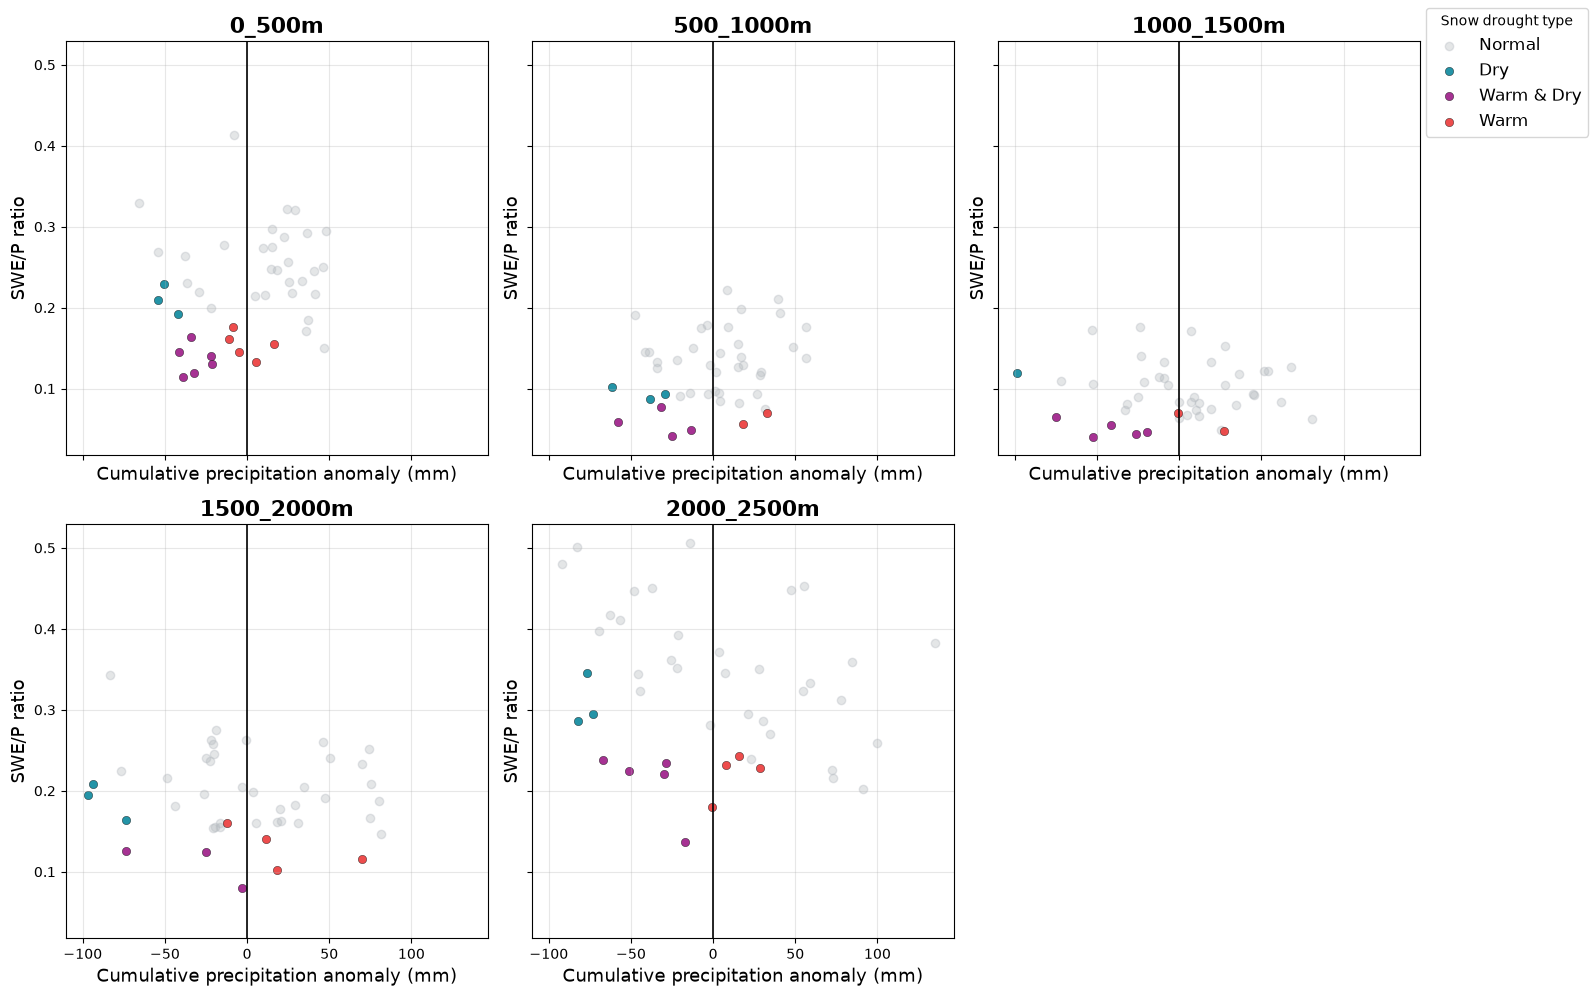

In [20]:
# Plot drought-year k-means classification in physical variable space.
cluster_colors = {
    "Warm": "#EB3A3A",
    "Warm & Dry": "#9C1C87",
    "Dry": "#0C889E",
    "Normal": "#B2B8BD",
}

elev_order = ["0_500m", "500_1000m", "1000_1500m", "1500_2000m", "2000_2500m"]
elevations_ordered = [e for e in elev_order if e in classification_all_years["elev_class"].unique()]

ncols = 3
nrows = int(np.ceil(len(elevations_ordered) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()

for i, elev in enumerate(elevations_ordered):
    ax = axes[i]
    elev_all = classification_all_years[classification_all_years["elev_class"] == elev]

    # Plot non-drought years lightly as background.
    normal_points = elev_all[elev_all["cluster_name"] == "Normal"]
    ax.scatter(
        normal_points["Avg_Cum_P_anomaly"],
        normal_points["Avg_SWE_P_ratio"],
        color=cluster_colors["Normal"],
        alpha=0.35,
        label="Normal" if i == 0 else ""
    )

    # Plot classified drought years on top.
    for cname in ["Dry", "Warm & Dry", "Warm"]:
        pts = elev_all[elev_all["cluster_name"] == cname]
        ax.scatter(
            pts["Avg_Cum_P_anomaly"],
            pts["Avg_SWE_P_ratio"],
            color=cluster_colors[cname],
            alpha=0.9,
            edgecolor="black",
            linewidth=0.3,
            label=cname if i == 0 else ""
        )

    ax.axvline(0, color="black", linewidth=1.2)
    ax.set_title(elev, fontsize=16, fontweight="bold")
    ax.set_xlabel("Cumulative precipitation anomaly (mm)", fontsize=13)
    ax.set_ylabel("SWE/P ratio", fontsize=13)
    ax.grid(True, alpha=0.3)

for j in range(len(elevations_ordered), len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Snow drought type", loc="upper right", fontsize=12)
plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.savefig(config['output_plots'] / 'Snow_Drought_Classification_by_Elevation_clean.png', dpi=1000, bbox_inches='tight')
plt.show()

In [21]:
# Summary table: drought years separated by type, plus any unmatched/missing years.
# unmatched should be empty unless a SWEI drought year is missing from classification_all_years.

type_to_col = {
    "Dry": "dry",
    "Warm & Dry": "dry&warm",
    "Warm": "warm",
}

summary_rows = []
for elev in elevations_ordered:
    row = {"elev_class": elev}

    requested = set(
        drought_years_long.loc[drought_years_long["elev_class"] == elev, "Seasonal_Year"]
        .dropna()
        .astype(int)
        .tolist()
    )

    matched_for_elev = set(
        classification_all_years.loc[
            (classification_all_years["elev_class"] == elev) &
            (classification_all_years["is_swei_drought"]),
            "Seasonal_Year"
        ].dropna().astype(int).tolist()
    )

    assigned = set()
    for cname, col in type_to_col.items():
        years = classification_all_years.loc[
            (classification_all_years["elev_class"] == elev) &
            (classification_all_years["cluster_name"] == cname),
            "Seasonal_Year"
        ].dropna().astype(int).unique().tolist()
        years = sorted(years)
        row[col] = years
        assigned.update(years)

    row["Drought_Years"] = sorted(requested)
    row["unmatched"] = sorted(requested - assigned)
    row["missing_from_classification_data"] = sorted(requested - matched_for_elev)
    summary_rows.append(row)

sd_years_df = pd.DataFrame(summary_rows)
display(sd_years_df)

# Optional export
# sd_years_df.to_csv(config['output_dir'] / 'Snow_Drought_Years_by_Type_clean.csv', index=False)

,elev_class,dry,dry&warm,warm,Drought_Years,unmatched,missing_from_classification_data
0,0_500m,"[1997, 1998, 2001]","[1983, 1992, 2002, 2005, 2014, 2016]","[2000, 2003, 2009, 2011, 2023]","[1983, 1992, 1997, 1998, 2000, 2001, 2002, 200...",[],[]
1,500_1000m,"[1987, 1997, 1999]","[1992, 2000, 2005, 2023]","[2011, 2016]","[1987, 1992, 1997, 1999, 2000, 2005, 2011, 201...",[],[]
2,1000_1500m,[1987],"[1997, 1999, 2000, 2004, 2005]","[2011, 2015]","[1987, 1997, 1999, 2000, 2004, 2005, 2011, 2015]",[],[]
3,1500_2000m,"[1986, 1987, 2000]","[1997, 2004, 2005]","[1998, 2002, 2011, 2015]","[1986, 1987, 1997, 1998, 2000, 2002, 2004, 200...",[],[]
4,2000_2500m,"[1987, 2000, 2009]","[1996, 1997, 2004, 2005, 2015]","[1998, 2002, 2003, 2007]","[1987, 1996, 1997, 1998, 2000, 2002, 2003, 200...",[],[]


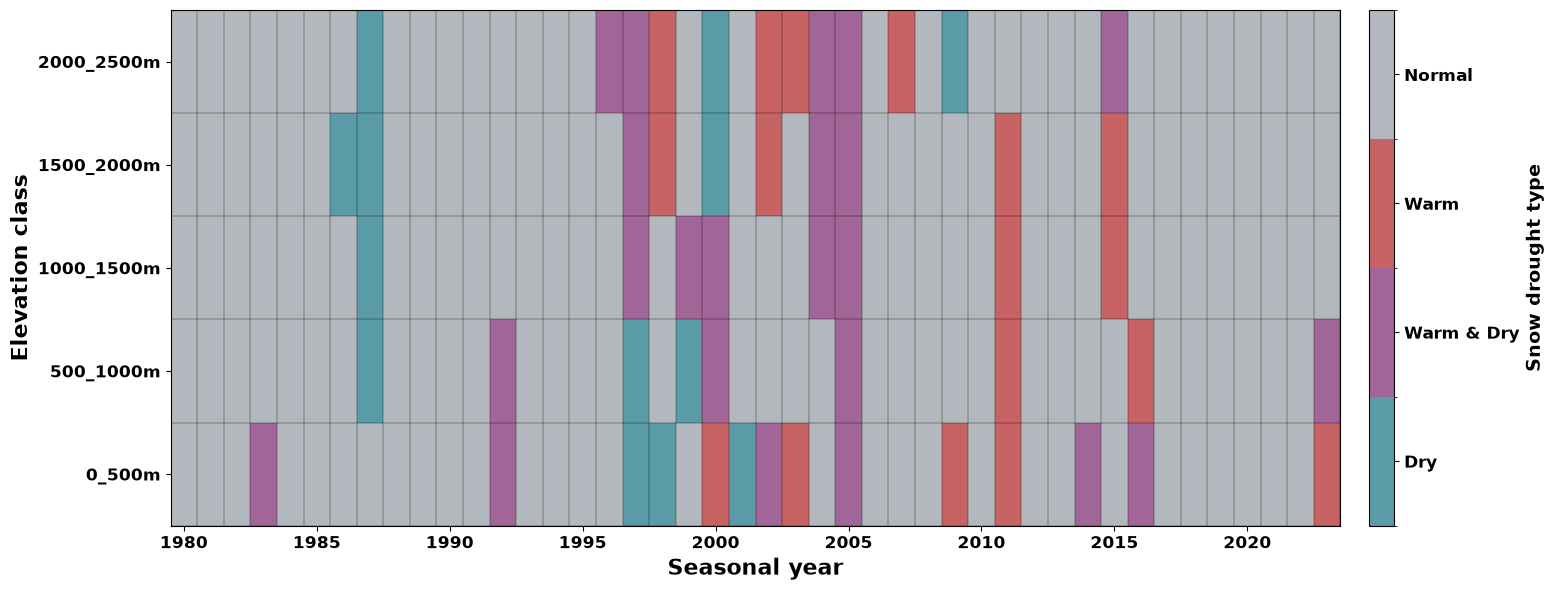

In [ ]:
# Heatmap of final snow drought classification.
# Normal = years that are not SWEI drought years.
drought_type_colors = {
    "Dry": "#599CA8",
    "Warm & Dry": "#A16597",
    "Warm": "#C76363",
    "Normal": "#B2B8BD",
}

class_to_value = {
    "Dry": 1,
    "Warm & Dry": 2,
    "Warm": 3,
    "Normal": 4,
}

plot_df = classification_all_years.copy()
plot_df["type_value"] = plot_df["cluster_name"].map(class_to_value)

all_years = sorted(plot_df["Seasonal_Year"].dropna().astype(int).unique())
elevations_ordered = [e for e in elev_order if e in plot_df["elev_class"].unique()]

heatmap_data = np.full((len(elevations_ordered), len(all_years)), np.nan)
for i, elev in enumerate(elevations_ordered):
    elev_df = plot_df[plot_df["elev_class"] == elev]
    year_to_value = dict(zip(elev_df["Seasonal_Year"].astype(int), elev_df["type_value"]))
    for j, year in enumerate(all_years):
        heatmap_data[i, j] = year_to_value.get(year, np.nan)

cmap = ListedColormap([
    drought_type_colors["Dry"],
    drought_type_colors["Warm & Dry"],
    drought_type_colors["Warm"],
    drought_type_colors["Normal"],
])
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heatmap_data, aspect="auto", cmap=cmap, norm=norm)

# X-axis ticks every 5 years
all_years_arr = np.array(all_years)
tick_years = np.arange(all_years_arr.min(), all_years_arr.max() + 1, 5)
tick_pos = [np.where(all_years_arr == y)[0][0] for y in tick_years if y in all_years_arr]
ax.set_xticks(tick_pos)
ax.set_xticklabels([str(y) for y in tick_years if y in all_years_arr], fontsize=12, fontweight="bold")

ax.set_yticks(np.arange(len(elevations_ordered)))
ax.set_yticklabels(elevations_ordered, fontsize=12, fontweight="bold")
ax.invert_yaxis()

ax.set_xlabel("Seasonal year", fontsize=16, fontweight="bold")
ax.set_ylabel("Elevation class", fontsize=16, fontweight="bold")

# Grid lines between cells
ax.set_xticks(np.arange(-0.5, len(all_years), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(elevations_ordered), 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, ticks=[1, 2, 3, 4], pad=0.02)
cbar.set_ticklabels(["Dry", "Warm & Dry", "Warm", "Normal"], fontsize=12, fontweight="bold")
cbar.set_label("Snow drought type", fontsize=14, fontweight="bold")

plt.tight_layout()
# plt.savefig(config['output_plots'] / 'Snow_Drought_Classification_Heatmap_clean.png', dpi=1000, bbox_inches='tight')
plt.show()

## Method note for thesis/paper

This workflow treats snow drought typing as a two-stage process. First, SWEI is used to identify snow drought years for each elevation class. Then, only those SWEI drought years are classified into physical drought types using standardized SWE/P ratio and cumulative precipitation anomaly. Non-drought years are assigned as Normal after the clustering step. This prevents normal years from influencing the drought-type cluster boundaries and avoids hard-coded cluster IDs that change across datasets.